# Task 2: Predict Future Stock Prices (Short-Term)

**Objective:** Use historical stock data to predict the next day's closing price.

**Dataset:** Stock market data from Yahoo Finance, retrieved using the `yfinance` Python library.

**Approach:** We build two types of models —
1. **Regression models** (Linear Regression and Random Forest) using `Open`, `High`, `Low`, and `Volume` as features to predict the next day's `Close` price.
2. **A classical time series model (ARIMA)** that forecasts `Close` price purely from its own past values (moving-average style).

We then plot actual vs. predicted closing prices for all models to compare performance.

## 1. Install & Import Libraries

If `yfinance` or `statsmodels` aren't installed yet, uncomment the pip install line below.

In [1]:
# !pip install yfinance scikit-learn statsmodels matplotlib pandas numpy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
import warnings
# warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Select a Stock and Fetch Historical Data

We use **Apple (AAPL)** as the example stock. Feel free to change the ticker to any other symbol (e.g., `TSLA`, `MSFT`, `GOOGL`).

We pull about 4 years of daily historical data.

In [2]:
TICKER = "AAPL"  # change this to any stock symbol you like, e.g. "TSLA"
START_DATE = "2021-01-01"
END_DATE = None  # None = up to today

df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
df = df.reset_index()
print("Shape:", df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (1372, 6)


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2021-01-04,125.740852,129.821767,123.165986,129.734322,143301900
1,2021-01-05,127.295502,128.004815,124.788650,125.235614,97664900
2,2021-01-06,123.010536,127.334371,122.796773,124.098784,155088000
3,2021-01-07,127.208031,127.897907,124.234793,124.720617,109578200
4,2021-01-08,128.306015,128.869572,126.537610,128.675231,105158200


**Note:** `auto_adjust=True` adjusts prices for splits/dividends, which is standard practice for clean modeling. If the download is empty, check your internet connection or try a different date range/ticker.

## 3. Inspect the Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1372 non-null   datetime64[ns]
 1   (Close, AAPL)   1372 non-null   float64       
 2   (High, AAPL)    1372 non-null   float64       
 3   (Low, AAPL)     1372 non-null   float64       
 4   (Open, AAPL)    1372 non-null   float64       
 5   (Volume, AAPL)  1372 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 64.4 KB


In [4]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
count,1372,1372.000000,1372.000000,1372.000000,1372.000000,1.372000e+03
mean,2023-09-25 14:39:32.011661824,187.150997,189.017288,185.131001,186.984982,6.795331e+07
min,2021-01-04 00:00:00,113.229805,117.161141,113.083839,115.827969,1.791060e+07
25%,2022-05-12 18:00:00,147.601383,148.785737,145.523979,146.954391,4.680948e+07
50%,2023-09-25 12:00:00,175.473228,177.212922,174.028230,175.296923,6.039875e+07
75%,2025-02-06 06:00:00,223.201099,225.159479,221.335981,223.157435,8.200808e+07
max,2026-06-22 00:00:00,315.200012,317.399994,309.649994,314.179993,3.186799e+08
std,NaN,46.622817,46.998720,46.252584,46.604087,2.961124e+07


## 4. Visualize Raw Closing Price History

Always look at the raw series before modeling anything.

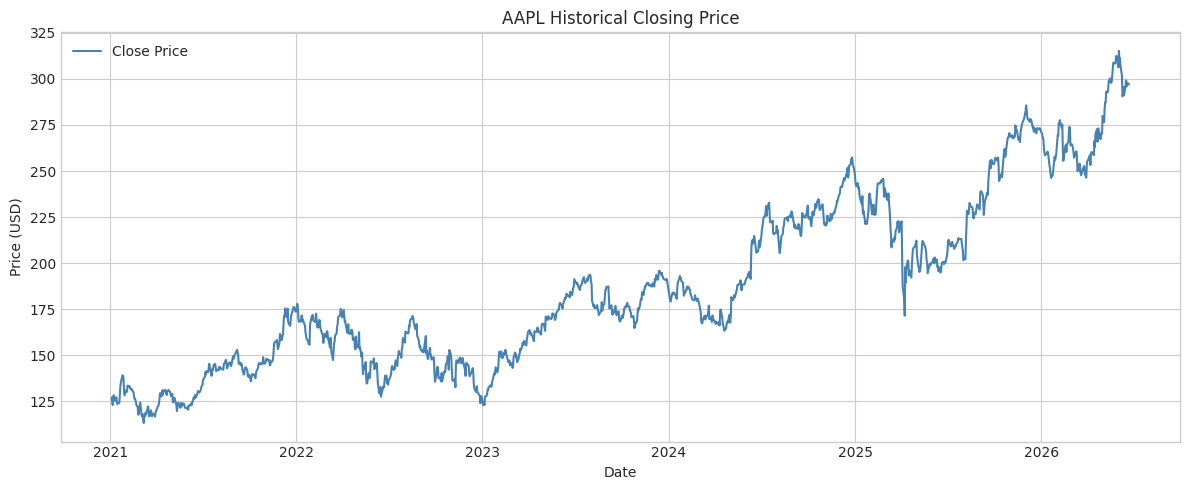

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close Price', color='steelblue')
plt.title(f'{TICKER} Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Feature Engineering

To predict the **next day's** closing price, we:
- Use `Open`, `High`, `Low`, `Volume`, and `Close` of the *current* day as features.
- Shift the `Close` column up by one row to create the **target** (`Next_Close`), which represents tomorrow's closing price.
- Drop the last row (it won't have a `Next_Close` value after shifting).

In [6]:
data = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Target: next day's close price
data['Next_Close'] = data['Close'].shift(-1)

# Drop last row (no next-day target available)
data = data.dropna().reset_index(drop=True)

data.head()

Price,Date,Open,High,Low,Close,Volume,Next_Close
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2021-01-04,129.734322,129.821767,123.165986,125.740852,143301900,127.295502
1,2021-01-05,125.235614,128.004815,124.788650,127.295502,97664900,123.010536
2,2021-01-06,124.098784,127.334371,122.796773,123.010536,155088000,127.208031
3,2021-01-07,124.720617,127.897907,124.234793,127.208031,109578200,128.306015
4,2021-01-08,128.675231,128.869572,126.537610,128.306015,105158200,125.323036


## 6. Train/Test Split

For time series, we must **not shuffle** the data. We use the earliest ~80% of rows for training and the most recent ~20% for testing, mimicking a real-world forecasting scenario.

In [7]:
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
target_col = 'Next_Close'

split_idx = int(len(data) * 0.8)

train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print("Train size:", len(train), " Test size:", len(test))

Train size: 1096  Test size: 275


## 7. Model 1 — Linear Regression

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression -> MSE: {lr_mse:.2f}, MAE: {lr_mae:.2f}, R2: {lr_r2:.4f}")

Linear Regression -> MSE: 13.35, MAE: 2.64, R2: 0.9856


## 8. Model 2 — Random Forest Regressor

In [9]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest -> MSE: {rf_mse:.2f}, MAE: {rf_mae:.2f}, R2: {rf_r2:.4f}")

Random Forest -> MSE: 370.84, MAE: 12.72, R2: 0.5994


## 9. Model 3 — ARIMA (Classical Time Series / Moving-Average Style Model)

Unlike the regression models above, ARIMA uses **only the historical Close price series itself** (no Open/High/Low/Volume features) to forecast future values. This is the classical time-series approach requested in the task.

We fit ARIMA on the training portion of the `Close` series and forecast over the test period.

In [10]:
close_train = train['Close'].reset_index(drop=True)
close_test = test['Close'].reset_index(drop=True)

# ARIMA(p, d, q) - a reasonable general-purpose starting point.
# p=5 (autoregressive lags), d=1 (first differencing for trend/non-stationarity), q=0 (no MA term)
arima_model = ARIMA(close_train, order=(5, 1, 0))
arima_fit = arima_model.fit()

# Forecast same number of steps as the test set
arima_forecast = arima_fit.forecast(steps=len(close_test))
arima_forecast = arima_forecast.reset_index(drop=True)

arima_mse = mean_squared_error(close_test, arima_forecast)
arima_mae = mean_absolute_error(close_test, arima_forecast)

print(f"ARIMA -> MSE: {arima_mse:.2f}, MAE: {arima_mae:.2f}")

ARIMA -> MSE: 2698.17, MAE: 44.47


**Note on ARIMA:** Predicting the *next day's* close from only past close prices is a hard problem — stock prices are close to a random walk, so ARIMA forecasts often look close to a flat/slowly drifting line compared to the more reactive regression models. This is expected and is itself an important takeaway about market predictability, not a bug in the model.

## 10. Model Comparison Table

In [11]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'ARIMA'],
    'MAE': [lr_mae, rf_mae, arima_mae],
    'MSE': [lr_mse, rf_mse, arima_mse]
})
results

,Model,MAE,MSE
0,Linear Regression,2.641003,13.348005
1,Random Forest,12.717623,370.844323
2,ARIMA,44.474718,2698.167049


**How to read this:** Lower MAE/MSE means more accurate predictions. Typically, Linear Regression performs strongly here because next-day Close is highly correlated with the current day's Open/High/Low/Close (stock prices move gradually day to day). Random Forest may overfit slightly on noisy short-term price data. ARIMA, relying only on past Close values, usually lags behind sharp price movements since it has no information about the same day's trading range or volume.

## 11. Plot — Actual vs Predicted Closing Prices (Regression Models)

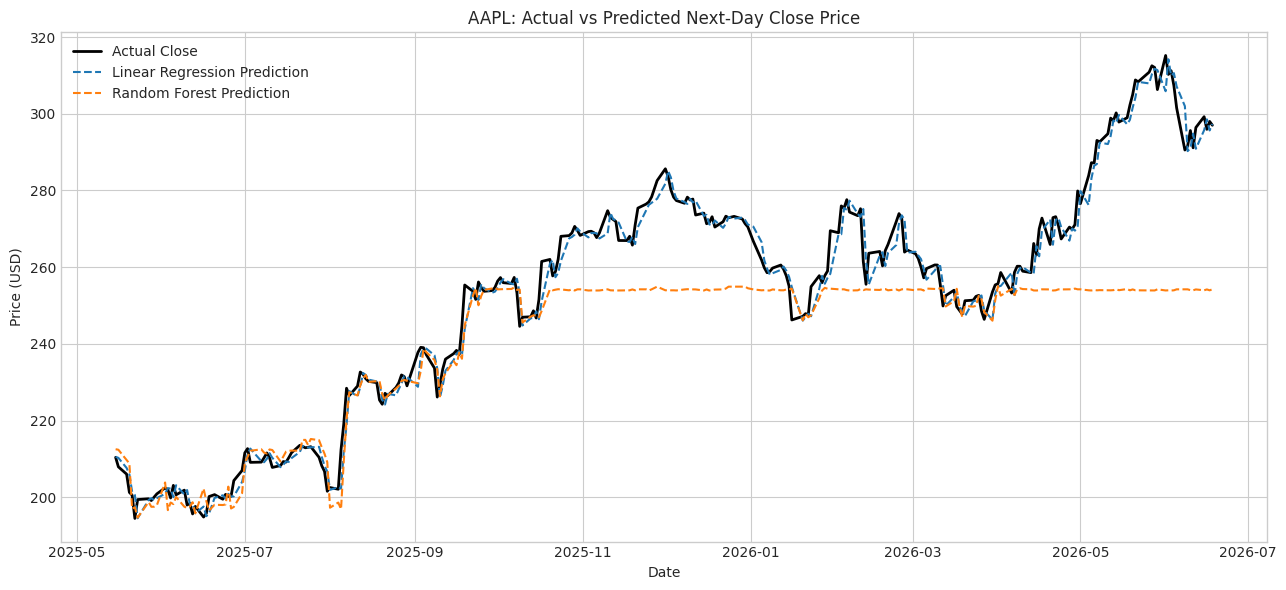

In [12]:
test_dates = test['Date'].reset_index(drop=True)

plt.figure(figsize=(13, 6))
plt.plot(test_dates, y_test.reset_index(drop=True), label='Actual Close', color='black', linewidth=2)
plt.plot(test_dates, lr_preds, label='Linear Regression Prediction', linestyle='--')
plt.plot(test_dates, rf_preds, label='Random Forest Prediction', linestyle='--')
plt.title(f'{TICKER}: Actual vs Predicted Next-Day Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Plot — Actual vs Predicted Closing Prices (ARIMA)

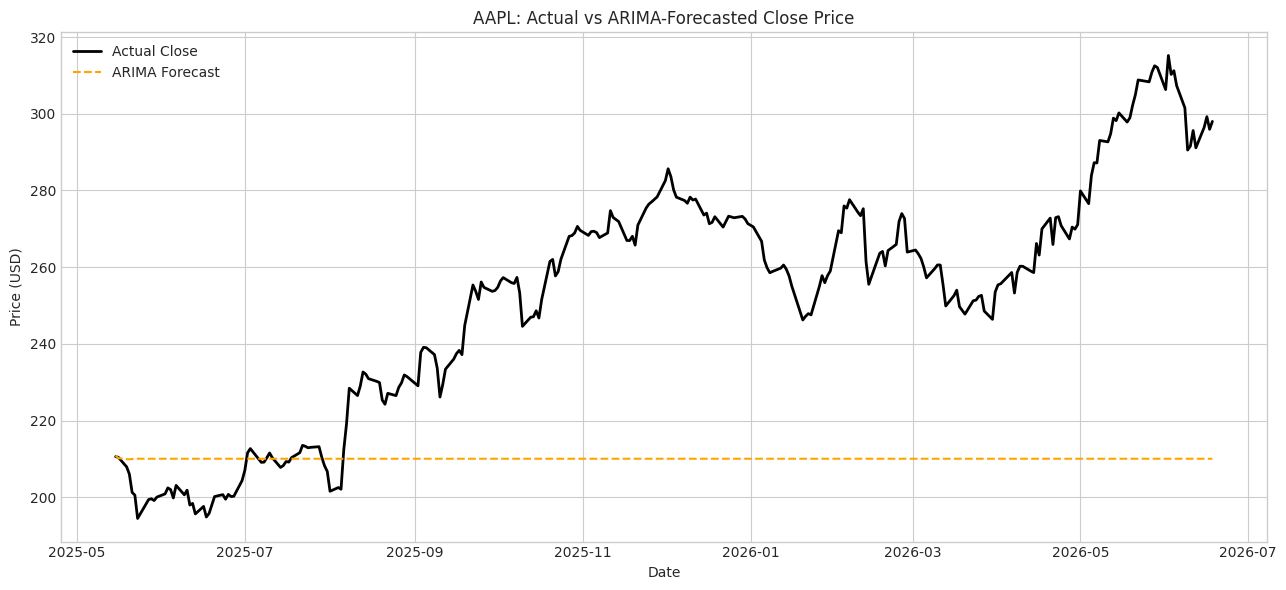

In [13]:
plt.figure(figsize=(13, 6))
plt.plot(test_dates, close_test, label='Actual Close', color='black', linewidth=2)
plt.plot(test_dates, arima_forecast, label='ARIMA Forecast', color='orange', linestyle='--')
plt.title(f'{TICKER}: Actual vs ARIMA-Forecasted Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Combined Comparison — All Models vs Actual

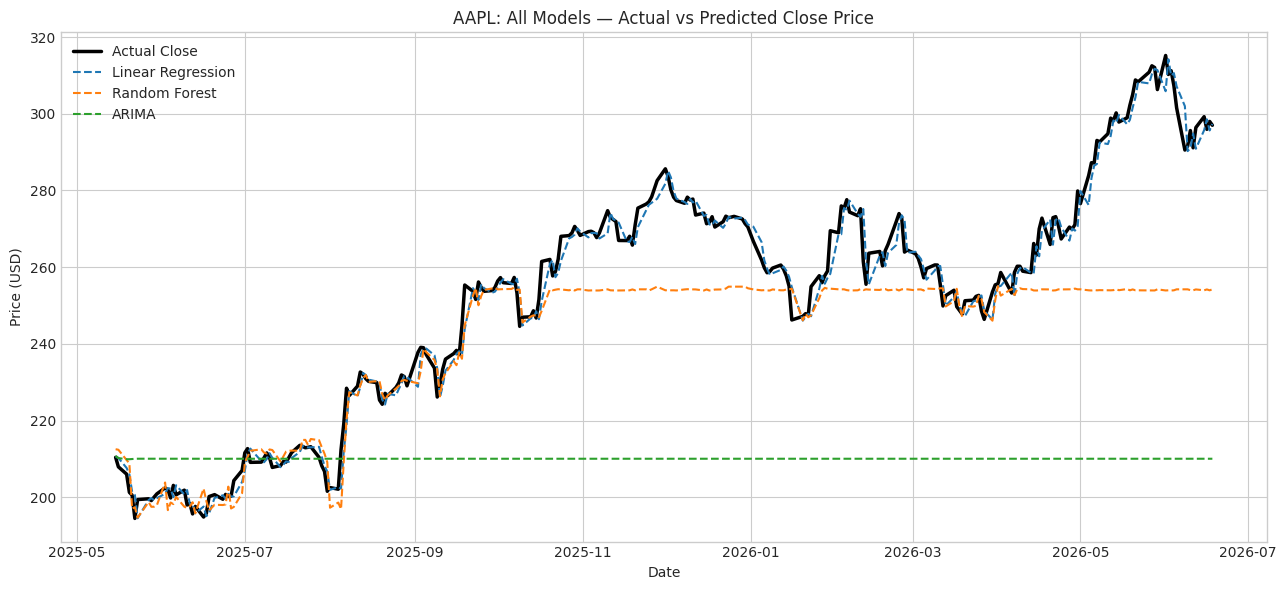

In [14]:
plt.figure(figsize=(13, 6))
plt.plot(test_dates, y_test.reset_index(drop=True), label='Actual Close', color='black', linewidth=2.5)
plt.plot(test_dates, lr_preds, label='Linear Regression', linestyle='--')
plt.plot(test_dates, rf_preds, label='Random Forest', linestyle='--')
plt.plot(test_dates, arima_forecast, label='ARIMA', linestyle='--')
plt.title(f'{TICKER}: All Models — Actual vs Predicted Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 14. Summary

- **Linear Regression** and **Random Forest** use same-day `Open/High/Low/Close/Volume` to predict the next day's close, and tend to track the actual price closely because today's price is a strong predictor of tomorrow's.
- **ARIMA** relies purely on the historical Close price sequence, with no same-day market information, so it tends to be smoother and can lag behind sudden price jumps.
- Comparing the MAE/MSE table and the plots above shows which approach fits this particular stock and time window best — re-run with a different `TICKER` or date range to see how results vary across stocks.
- **Disclaimer:** This notebook is for educational purposes only. Short-term stock price prediction is inherently noisy and uncertain; these models should not be used for real trading decisions.